# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abdulm111/ML-Assignement01/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Where this queue comes from.** The model is w05/w06's Random Forest (position, impressions, GA4
engagement, `has_ga4_month`, content_type → predicted CTR), grouped-by-client validated at R² =
0.146 (15.2% variance reduction vs. the tier-only baseline — see w06). This notebook reproduces
that validation fresh below, then **refits the same model on the full March panel** to generate the
operational queue. That's standard practice, not a retreat from honesty: the held-out numbers are
the trustworthy estimate of *how well this generalizes*; refitting on everything before scoring the
current, known set of pages is how the model gets to use all available signal for the actual
deployed artifact. The queue's claimed confidence rests on the held-out numbers recomputed below,
not on any in-sample fit statistic.

**Reason codes and archetypes, built from features we've actually validated — not imported from the
paper's clusters.** The paper's own Content Archetypes (page 26) carry an explicit caveat: 4 of its
5 k-means clusters got the same duplicated heuristic label ("Rising Stars"), and the paper says
outright *"the safer use is to compare cluster profiles, not to treat them as fixed operational
archetypes."* Three tiers instead, defined from features this model already validated plus real
freshness data:

- **`VISIBLE_UNDERPERFORMER`** (`top_3` / `page_1` tier, `ctr_gap > 0`) — already ranks well; the
  gap is about click appeal (title/snippet/meta), not visibility.
- **`AGING_NEEDS_REFRESH`** (`striking` / `page_3_5` tier, `ctr_gap > 0`, 180+ days since last
  update) — close to breaking through *and* stale.
- **`RISING_OPPORTUNITY`** (`striking` / `page_3_5` tier, `ctr_gap > 0`, not yet stale).
- Confidence overlay: **`LOW_VOLUME`** (< 300 impressions) or **`NO_GA4`** (`has_ga4_month == 0`),
  else **`OK`**. `deep`-tier pages excluded entirely, matching every prior week.

**Cost/value framing, revised after actually checking the output.** A first pass ranked the top 200
purely by `opportunity_score` (recoverable click volume). It produced **zero** `AGING_NEEDS_REFRESH`
pages — that reason code only fires on lower-traffic tiers, which can never win a pure
volume-weighted ranking no matter how real the issue is. A queue that names three action types but
only ever produces one isn't an archetype mapping, it's decoration. Fixed with a **quota across
reason_code** — 100 `VISIBLE_UNDERPERFORMER` / 60 `RISING_OPPORTUNITY` / 40 `AGING_NEEDS_REFRESH`,
each internally still ranked by `opportunity_score` — so the queue actually reflects the mix of
interventions it claims to. `LOW_VOLUME` pages are *also* absent from the top ranks and that's left
alone deliberately: a thin page genuinely has less value at stake, so being ranked low is the
correct behavior for a value-ordered queue, not a gap to quota-fix.

**The decay/refresh insight — checked against our own panel, and the result is genuinely mixed.**
FlyRank's Finding #1 (page 6) found declining content is on average 20% older and 37.6% shorter than
growing content. Our own check, underperforming (`ctr_gap > 0`) vs. at-or-above-expected pages:
- `content_age_days`: **195 vs. 177** (~10% older) — same direction as the paper, smaller effect.
- `days_since_update`: **101 vs. 93** (~9% longer since last edit) — same direction, smaller effect.
- `word_count`: **checked, and the comparison itself doesn't hold up.** Raw means show
  underperforming pages averaging more words (3,012 vs. 2,884) — the opposite of the paper's
  direction — but 28.5% of rows are missing `word_count` overall, and that missingness is **not**
  balanced across the two groups: 31.9% missing among underperformers vs. 21.6% among
  at-or-above-expected pages, a 10-point gap. The two means aren't computed from comparable
  populations, so neither direction — matching the paper or contradicting it — should be trusted
  from this check. Reported as inconclusive, not used either way.

One of three signals is unusable rather than contradicting; the other two (age, freshness) lean the
same direction as the paper's portfolio-wide finding with smaller effect sizes. This still doesn't
invalidate `AGING_NEEDS_REFRESH` — it's built from position tier and days-since-update, both of
which agree with the paper and have complete data — but it does mean no claim about content length
should be made from this panel in either direction.


In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Schema probe -- do we actually have content-age / last-updated fields in the
# warehouse's dim_content table? Check before assuming, per flyrank-data.
import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute("CREATE SECRET (TYPE huggingface, TOKEN ?)", [HF_TOKEN])
REL = "hf://datasets/FlyRank/internship-warehouse"

schema = con.sql(f"DESCRIBE SELECT * FROM read_parquet('{REL}/dim_content.parquet')").df()
print(schema.to_string())
print("\nLook for anything like content_age_days / days_since_last_update / published_date above.")
print("If present: tell your assistant the exact column name(s) so the decay insight below can use real data.")

                   column_name column_type null   key default extra
0               client_hash_id     VARCHAR  YES  None    None  None
1              content_hash_id     VARCHAR  YES  None    None  None
2              keyword_hash_id     VARCHAR  YES  None    None  None
3                  url_hash_id     VARCHAR  YES  None    None  None
4           keyword_char_count      BIGINT  YES  None    None  None
5          keyword_token_count      BIGINT  YES  None    None  None
6               url_char_count      BIGINT  YES  None    None  None
7         content_created_date        DATE  YES  None    None  None
8         content_updated_date        DATE  YES  None    None  None
9                 content_type     VARCHAR  YES  None    None  None
10               search_volume      BIGINT  YES  None    None  None
11                 competition      DOUBLE  YES  None    None  None
12           competition_level     VARCHAR  YES  None    None  None
13                         cpc      DOUBLE  YES 

In [6]:
# Same modeling panel as w05/w06 -- identical filters and features, now also
# pulling real content-age/freshness fields confirmed present by the schema probe.
import numpy as np, pandas as pd

MONTH = "2026-03"
con.execute(f"""
    CREATE OR REPLACE TABLE march_facts AS
    SELECT * FROM read_parquet('{REL}/fact_content_daily_performance/month={MONTH}/*.parquet')
""")

gsc_monthly = con.sql("""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS impressions_month,
           SUM(gsc_clicks) AS clicks_month,
           SUM(gsc_avg_position * gsc_impressions) / NULLIF(SUM(gsc_impressions), 0) AS avg_position_month
    FROM march_facts WHERE gsc_data_available IS TRUE GROUP BY 1, 2
""").df()

ga4_monthly = con.sql("""
    SELECT client_hash_id, content_hash_id,
           SUM(ga4_engaged_sessions) AS ga4_engaged_sessions_month,
           SUM(sessions_ai) AS sessions_ai_month,
           SUM(scroll_events) AS scroll_events_month,
           COUNT(*) AS ga4_days_available
    FROM march_facts WHERE ga4_data_available IS TRUE GROUP BY 1, 2
""").df()

monthly = gsc_monthly.merge(ga4_monthly, on=["client_hash_id", "content_hash_id"], how="left")
monthly["has_ga4_month"] = monthly["ga4_days_available"].notna().astype(int)
for c in ["ga4_engaged_sessions_month", "sessions_ai_month", "scroll_events_month"]:
    monthly[c] = monthly[c].fillna(0)
monthly = monthly.drop(columns=["ga4_days_available"])
monthly["position_tier"] = np.select(
    [monthly["avg_position_month"] <= 3, monthly["avg_position_month"] <= 10,
     monthly["avg_position_month"] <= 20, monthly["avg_position_month"] <= 50],
    ["top_3", "page_1", "striking", "page_3_5"], default="deep"
)

content = con.sql(f"""
    SELECT content_hash_id, content_type, is_published, is_deleted,
           content_created_date, content_updated_date, word_count
    FROM read_parquet('{REL}/dim_content.parquet')
""").df()

q = monthly.merge(content, on="content_hash_id", how="inner")
q = q[(q["is_published"] == True) & (q["is_deleted"] == False)]
q = q[(q["impressions_month"] >= 100) & (q["avg_position_month"] >= 1)].copy()
q["ctr"] = q["clicks_month"] / q["impressions_month"]

REPORT_DATE = pd.Timestamp("2026-03-31")
TODAY = pd.Timestamp.now().normalize()

# content_age_days: age AS OF the March reporting period (answers "was this
# page old when we measured its March CTR") -- content_created_date is fixed
# per row, so this is safe regardless of reference date.
q["content_age_days"] = (REPORT_DATE - pd.to_datetime(q["content_created_date"])).dt.days

# days_since_update: staleness AS OF TODAY (answers "is this overdue for a
# refresh right now"). NOT measured from REPORT_DATE: dim_content is a
# current-state table, so content_updated_date is very often AFTER March
# (content keeps getting edited after the reporting month) -- measuring from
# REPORT_DATE would produce nonsensical negative "days since update" for most
# pages. TODAY is the right reference for an action-oriented signal.
q["days_since_update"] = (TODAY - pd.to_datetime(q["content_updated_date"])).dt.days

print(f"Modeling panel: {len(q)} rows, {q['client_hash_id'].nunique()} clients")
print(f"Missing content_age_days: {q['content_age_days'].isna().sum()}, "
      f"missing days_since_update: {q['days_since_update'].isna().sum()}")
print(f"days_since_update range: {q['days_since_update'].min()} to {q['days_since_update'].max()} "
      f"(should be non-negative now)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling panel: 100702 rows, 44 clients
Missing content_age_days: 0, missing days_since_update: 0
days_since_update range: 54 to 415 (should be non-negative now)


In [7]:
# Fresh grouped-split validation (reproduces w05/w06's headline numbers in
# THIS run, so the metrics JSON exported in Section 5 is self-contained
# rather than quoting last week's numbers from memory).
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

FEATURE_COLS = ["avg_position_month", "impressions_month", "ga4_engaged_sessions_month",
                 "sessions_ai_month", "scroll_events_month", "has_ga4_month"]

def make_X(df, ref_cols=None):
    X = pd.get_dummies(df[FEATURE_COLS + ["content_type"]], columns=["content_type"])
    return X.reindex(columns=ref_cols, fill_value=0) if ref_cols is not None else X

tier_mean_full = q.groupby("position_tier")["ctr"].mean()
global_mean_full = q["ctr"].mean()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(gss.split(q, groups=q["client_hash_id"]))
g_train, g_test = q.iloc[tr_idx], q.iloc[te_idx]

train_X = make_X(g_train)
test_X = make_X(g_test, train_X.columns)
rf_validate = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                     random_state=42, n_jobs=-1).fit(train_X, g_train["ctr"])
pred = rf_validate.predict(test_X)

tier_pred = g_test["position_tier"].map(tier_mean_full).fillna(global_mean_full)
tier_mse = mean_squared_error(g_test["ctr"], tier_pred)
model_mse = mean_squared_error(g_test["ctr"], pred)

validated_metrics = {
    "r2_vs_test_mean": round(r2_score(g_test["ctr"], pred), 4),
    "mae_ctr_pts": round(mean_absolute_error(g_test["ctr"], pred), 4),
    "pct_variance_reduction_vs_tier_baseline": round((1 - model_mse / tier_mse) * 100, 2),
    "base_rate_mean_ctr": round(g_test["ctr"].mean(), 4),
    "test_clients": int(g_test["client_hash_id"].nunique()),
    "validation_split": "grouped_by_client",
}
print("Validated performance (grouped-by-client split, recomputed this run):")
validated_metrics

Validated performance (grouped-by-client split, recomputed this run):


{'r2_vs_test_mean': 0.1455,
 'mae_ctr_pts': 0.0032,
 'pct_variance_reduction_vs_tier_baseline': 15.14,
 'base_rate_mean_ctr': np.float64(0.004),
 'test_clients': 9,
 'validation_split': 'grouped_by_client'}

In [8]:
# Refit on the FULL panel for the deployed queue (standard practice once
# validation is done -- see markdown above), then score every eligible page.
full_X = make_X(q)
rf_final = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                  random_state=42, n_jobs=-1).fit(full_X, q["ctr"])
q["predicted_ctr"] = rf_final.predict(full_X)
q["ctr_gap"] = q["predicted_ctr"] - q["ctr"]
q["opportunity_score"] = q["ctr_gap"] * q["impressions_month"]

# Own-panel decay/refresh check. Count missingness before averaging over it --
# a directional claim built on silently-dropped rows needs to say so.
missing_wc = q["word_count"].isna().sum()
print(f"Missing word_count: {missing_wc} of {len(q)} rows ({missing_wc/len(q):.1%}) "
      f"-- excluded from the mean below by pandas default, not imputed as zero")

missing_wc = q["word_count"].isna().sum()
print(f"Missing word_count: {missing_wc} of {len(q)} rows ({missing_wc/len(q):.1%}) "
      f"-- excluded from the mean below by pandas default, not imputed as zero")

# Is that missingness balanced across the two groups being compared, or does
# it skew the word_count check specifically? content_age_days/days_since_update
# have zero missingness (confirmed above), so this is a word_count-only concern.
missing_by_group = q.groupby(q["ctr_gap"] > 0)["word_count"].apply(lambda s: s.isna().mean())
print(f"Missing word_count rate -- underperforming: {missing_by_group.get(True, float('nan')):.1%}, "
      f"at/above expected: {missing_by_group.get(False, float('nan')):.1%}")

decay_check_cols = ["word_count", "content_age_days", "days_since_update"]
own_panel_check = pd.DataFrame({
    "underperforming (ctr_gap > 0)": q.loc[q["ctr_gap"] > 0, decay_check_cols].mean(),
    "at/above expected (ctr_gap <= 0)": q.loc[q["ctr_gap"] <= 0, decay_check_cols].mean(),
})
print("\nOwn-panel decay/refresh check (mean values):")
print(own_panel_check)
print()

eligible = q[(q["position_tier"] != "deep") & (q["ctr_gap"] > 0)].copy()

STALE_DAYS = 180  # ~6 months, matching FlyRank Finding #1's quarterly-review window

def reason_code(row):
    if (row["position_tier"] in ("striking", "page_3_5")
            and pd.notna(row["days_since_update"]) and row["days_since_update"] >= STALE_DAYS):
        return "AGING_NEEDS_REFRESH"
    if row["position_tier"] in ("top_3", "page_1"):
        return "VISIBLE_UNDERPERFORMER"
    return "RISING_OPPORTUNITY"

def confidence_flag(row):
    if row["impressions_month"] < 300:
        return "LOW_VOLUME"
    if row["has_ga4_month"] == 0:
        return "NO_GA4"
    return "OK"

ACTION_TEXT = {
    "VISIBLE_UNDERPERFORMER": "Review title, meta description, and SERP snippet -- the page already "
                               "ranks well, so the gap is about click appeal, not visibility.",
    "RISING_OPPORTUNITY": "Review content depth -- close to page 1 and not yet flagged as stale; "
                           "expanding coverage is the more likely lever.",
    "AGING_NEEDS_REFRESH": f"Prioritize a full content refresh -- {STALE_DAYS}+ days since last update. "
                            "Note: our own panel found underperforming pages average MORE words than "
                            "the rest, not fewer -- don't default to 'add more words' here; diagnose "
                            "the actual page.",
}

eligible["reason_code"] = eligible.apply(reason_code, axis=1)
eligible["confidence_flag"] = eligible.apply(confidence_flag, axis=1)
eligible["suggested_action"] = eligible["reason_code"].map(ACTION_TEXT)

print("Reason code counts across the FULL eligible pool:")
print(eligible["reason_code"].value_counts())
print()

queue_cols = [
    "client_hash_id", "content_hash_id", "position_tier", "content_type",
    "avg_position_month", "impressions_month", "word_count", "content_age_days",
    "days_since_update", "ctr", "predicted_ctr", "ctr_gap", "opportunity_score",
    "reason_code", "confidence_flag", "suggested_action",
]
eligible_sorted = eligible.sort_values("opportunity_score", ascending=False)[queue_cols].reset_index(drop=True)

# Quota across reason_code, not a single global top-200 cut -- a pure
# opportunity_score cut produced ZERO AGING_NEEDS_REFRESH pages (see markdown):
# that tier structurally gets less traffic and can never win a volume-weighted
# ranking. Quota guarantees the queue actually reflects all three action
# types it claims to, each still ranked by opportunity_score within its slice.
QUOTAS = {"VISIBLE_UNDERPERFORMER": 100, "RISING_OPPORTUNITY": 60, "AGING_NEEDS_REFRESH": 40}

queue_parts = []
for code, n in QUOTAS.items():
    pool = eligible_sorted[eligible_sorted["reason_code"] == code]
    queue_parts.append(pool.head(n))
    print(f"{code}: took top {min(n, len(pool))} of {len(pool)} eligible")

queue = pd.concat(queue_parts).sort_values("opportunity_score", ascending=False).reset_index(drop=True)

print(f"\nEligible pool: {len(eligible_sorted)} pages. Priority queue (quota-based, {sum(QUOTAS.values())}): {len(queue)} pages.")
print("\nReason code counts in the priority queue:")
print(queue["reason_code"].value_counts())
print("\nConfidence flag counts in the priority queue:")
print(queue["confidence_flag"].value_counts())
queue.head(10)

Missing word_count: 28710 of 100702 rows (28.5%) -- excluded from the mean below by pandas default, not imputed as zero
Missing word_count: 28710 of 100702 rows (28.5%) -- excluded from the mean below by pandas default, not imputed as zero
Missing word_count rate -- underperforming: 31.5%, at/above expected: 22.2%

Own-panel decay/refresh check (mean values):
                   underperforming (ctr_gap > 0)  \
word_count                           3006.688312   
content_age_days                       196.43111   
days_since_update                     102.088215   

                   at/above expected (ctr_gap <= 0)  
word_count                              2890.550628  
content_age_days                         174.335244  
days_since_update                         94.603273  

Reason code counts across the FULL eligible pool:
reason_code
VISIBLE_UNDERPERFORMER    37328
RISING_OPPORTUNITY        21432
AGING_NEEDS_REFRESH        5759
Name: count, dtype: int64

VISIBLE_UNDERPERFORMER: too

,client_hash_id,content_hash_id,position_tier,content_type,avg_position_month,impressions_month,word_count,content_age_days,days_since_update,ctr,predicted_ctr,ctr_gap,opportunity_score,reason_code,confidence_flag,suggested_action
0,client_23a62021009f63c4,content_e8a52cf3d5988c07,striking,keyword article,15.173490,244931.0,3477,230,79,0.002731,0.009073,0.006342,1553.301397,RISING_OPPORTUNITY,OK,Review content depth -- close to page 1 and no...
1,client_e547b89c05043229,content_0e03de7680314cd5,top_3,keyword article,2.506100,221310.0,2784,375,78,0.003253,0.009103,0.005849,1294.524032,VISIBLE_UNDERPERFORMER,OK,"Review title, meta description, and SERP snipp..."
2,client_e547b89c05043229,content_8d7d99f109e19aa2,top_3,keyword article,2.468557,203497.0,2895,375,78,0.001420,0.007121,0.005701,1160.151171,VISIBLE_UNDERPERFORMER,OK,"Review title, meta description, and SERP snipp..."
3,client_e547b89c05043229,content_4ffe18112a5642e3,top_3,keyword article,2.389966,186983.0,3097,375,78,0.003134,0.008211,0.005077,949.302594,VISIBLE_UNDERPERFORMER,OK,"Review title, meta description, and SERP snipp..."
4,client_e547b89c05043229,content_545bb6cc7081ded3,top_3,keyword article,2.524657,122905.0,2811,375,78,0.002335,0.008693,0.006357,781.365169,VISIBLE_UNDERPERFORMER,OK,"Review title, meta description, and SERP snipp..."
5,client_e547b89c05043229,content_ec2e0346994fb5a5,top_3,keyword article,2.757730,245276.0,2581,434,78,0.006034,0.009103,0.003069,752.679935,VISIBLE_UNDERPERFORMER,OK,"Review title, meta description, and SERP snipp..."
6,client_23a62021009f63c4,content_5e1c049f62e33b11,striking,keyword article,17.773364,120175.0,3142,230,79,0.001398,0.005513,0.004115,494.470480,RISING_OPPORTUNITY,OK,Review content depth -- close to page 1 and no...
7,client_73cda7b4e4f265ea,content_fe3fd3422852d721,page_1,keyword article,3.257834,124720.0,1038,259,64,0.002975,0.006920,0.003946,492.099947,VISIBLE_UNDERPERFORMER,OK,"Review title, meta description, and SERP snipp..."
8,client_e547b89c05043229,content_77276ad7a26f4905,page_1,keyword article,3.770494,116707.0,2674,467,68,0.001714,0.005795,0.004081,476.276966,VISIBLE_UNDERPERFORMER,OK,"Review title, meta description, and SERP snipp..."
9,client_73cda7b4e4f265ea,content_8e1334d6356668e3,top_3,keyword article,2.693038,134984.0,<NA>,410,68,0.000007,0.003387,0.003380,456.201246,VISIBLE_UNDERPERFORMER,OK,"Review title, meta description, and SERP snipp..."


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who this is for:** a FlyRank content strategist or editor deciding which *already-published*
pages to review this month, on a client they already manage. It's decision-support for prioritizing
manual review — not a tool that edits, publishes, or scores content automatically.

**What it's valid for:** CTR-underperformance ranking, within the March 2026 snapshot, for clients
and content types the model has actually seen (44 clients, overwhelmingly `keyword article` — see
w06's client/content-type confound finding). The queue tells you *which page to look at first*, not
*what specific change will fix it* — that's still a human judgment call informed by `reason_code`.

**Where it stops being valid:**
- **New or unpublished content.** No history for the model to score — cold start, out of scope.
- **New clients.** w05/w06 already showed both baselines and the frozen rule score *negative* R² on
  held-out clients, and content_type is nearly a client-level constant. A brand-new client's queue
  entries should be treated as low-confidence until re-validated on that client's own data.
- **A different month.** Single-month cross-section; no evidence this holds in a different season
  or after a Google algorithm update. Re-validate before trusting a queue from a stale model.
- **Anything below the 100-impression floor.** Excluded from the modeling panel entirely — this
  queue makes no claim about very-low-traffic pages.
- **Any metric other than CTR.** This says nothing about rankings, conversions, revenue, or traffic
  quality — CTR-vs-peers only.
- **Causal or promissory language.** Cross-sectional data, no intervention — decision-support only
  ("this page looks worth reviewing first, because…"), never "fixing this will raise CTR by X%."

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
intended_use = {
    "audience": "FlyRank content strategist / editor",
    "decision_supported": "which already-published page to manually review first, this month",
    "not_supported": ["auto-editing", "auto-publishing", "client-facing guarantees", "any metric besides CTR"],
    "valid_scope": {
        "clients": f"{q['client_hash_id'].nunique()} clients seen in training/validation",
        "content_types_seen": sorted(q["content_type"].unique().tolist()),
        "month": "2026-03 only",
        "impression_floor": 100,
    },
    "claim_language": "decision-support only -- 'worth reviewing first, because...', never causal",
}
import json
print(json.dumps(intended_use, indent=2))

{
  "audience": "FlyRank content strategist / editor",
  "decision_supported": "which already-published page to manually review first, this month",
  "not_supported": [
    "auto-editing",
    "auto-publishing",
    "client-facing guarantees",
    "any metric besides CTR"
  ],
  "valid_scope": {
    "clients": "44 clients seen in training/validation",
    "content_types_seen": [
      "comparison article",
      "feedly article",
      "keyword article"
    ],
    "month": "2026-03 only",
    "impression_floor": 100
  },
  "claim_language": "decision-support only -- 'worth reviewing first, because...', never causal"
}


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any row, a human checks:**
1. **Is the `confidence_flag` `OK`?** `LOW_VOLUME` and `NO_GA4` rows are still ranked, but the score
   is noisier — sanity-check the raw numbers before treating the rank as gospel.
2. **Is this seasonal or promotional content behaving as designed?** A page with an expected CTR dip
   (e.g., a holiday page in the off-season) will look like an "opportunity" to a model that has no
   concept of intent — the model can't tell "underperforming" from "doing exactly what it should."
3. **Is this page already scheduled for a rewrite, migration, or deprecation** for reasons outside
   this data? The queue doesn't know about editorial calendars.
4. **Does the `reason_code` make sense on inspection?** If a `VISIBLE_UNDERPERFORMER` row is
   actually a thin, low-quality page that happens to rank well by luck, the suggested action
   (snippet-level fix) is wrong — read the page, not just the row.
5. **On an `AGING_NEEDS_REFRESH` page, don't assume word count either way.** Our panel's word-count
   check turned out to be inconclusive — unequal missingness between the two groups being compared
   (see Section 1), not a confirmed contradiction of FlyRank's Finding #1. Diagnose the actual page
   rather than leaning on either the paper's number or ours.

**The no-go list — never automate these from this notebook's output:**
- **No auto-editing or auto-publishing.** This produces a review queue, not a content pipeline.
- **No auto-deleting, unpublishing, or de-indexing** based on a low score — that's irreversible and
  this model has never been validated for "should this page exist," only "is its CTR below peers."
- **No client-facing commitments** ("we will improve your CTR by X%") built on this queue — the
  model has not been validated for magnitude claims, only ranking.
- **No scoring of new clients or new content types** without flagging it as out-of-distribution
  first (see Section 2) — the queue will still produce a number, but the number is not trustworthy
  there.
- **No irreversible action taken from the model's score alone.** Every row needs a named human
  sign-off before anything changes on the live page.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
no_go_list = [
    "Auto-edit or auto-publish content changes",
    "Auto-delete, unpublish, or de-index a page based on score alone",
    "Make client-facing magnitude guarantees (\"this will raise CTR by X%\")",
    "Score new clients or new content types without an out-of-distribution flag",
    "Take any irreversible action without a named human sign-off",
]
review_checklist = [
    "confidence_flag is OK (else sanity-check the raw numbers first)",
    "Page isn't seasonal/promotional content behaving as intended",
    "Page isn't already scheduled for rewrite/migration/deprecation",
    "reason_code matches what a human reading the actual page would conclude",
]

print("NO-GO (never automate):")
for item in no_go_list:
    print(f"  - {item}")
print("\nHUMAN REVIEW CHECKLIST (before acting on any row):")
for item in review_checklist:
    print(f"  - {item}")


NO-GO (never automate):
  - Auto-edit or auto-publish content changes
  - Auto-delete, unpublish, or de-index a page based on score alone
  - Make client-facing magnitude guarantees ("this will raise CTR by X%")
  - Score new clients or new content types without an out-of-distribution flag
  - Take any irreversible action without a named human sign-off

HUMAN REVIEW CHECKLIST (before acting on any row):
  - confidence_flag is OK (else sanity-check the raw numbers first)
  - Page isn't seasonal/promotional content behaving as intended
  - Page isn't already scheduled for rewrite/migration/deprecation
  - reason_code matches what a human reading the actual page would conclude


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signals that this queue has gone stale, roughly in order of how fast they'd show up:**

1. **Coverage drift.** `has_ga4_month` rate or the `content_type` mix shifts noticeably from this
   run's baseline (this run: see printed rate below) — the model was validated on a specific data
   composition, and a materially different one deserves a re-check before trusting the queue.
2. **Baseline drift.** The frozen tier-only baseline's own MSE moves a lot on a fresh month — that's
   evidence the CTR landscape itself shifted (seasonality, a Google algorithm update), not just
   noise, and every downstream number in this notebook assumes a roughly stable landscape.
3. **New-client growth.** The client roster grows past the validated 44 — new clients are exactly
   the case w05/w06 showed the model (and the rule before it) struggles with most.
4. **Realized outcome check, next month.** The strongest signal: pull March's top-ranked
   `VISIBLE_UNDERPERFORMER` / `RISING_OPPORTUNITY` pages and check their April CTR. If the queue is
   working, reviewed pages should show more movement (in either direction — a human might have
   correctly decided not to act) than a random same-tier sample. If the gap between "flagged" and
   "random" pages disappears, that is the leading indicator to actually retrain.

**Retrain cadence:** monthly, as each new `month=` partition lands — this is a single-month
cross-sectional model with no time-awareness built in (see w05's split-design reasoning), so it
was never going to generalize across seasons by design. Retraining monthly is the honest match to
that limitation, not an arbitrary choice.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
monitoring_triggers = {
    "coverage_drift": {
        "this_run_has_ga4_rate": round(q["has_ga4_month"].mean(), 3),
        "this_run_content_type_mix": q["content_type"].value_counts(normalize=True).round(3).to_dict(),
        "trigger": "check if a fresh month's rates move meaningfully from these",
    },
    "baseline_drift": {
        "this_run_tier_only_mse_reference": round(tier_mse, 8),
        "trigger": "recompute on a fresh month; a large move suggests the landscape shifted",
    },
    "client_roster": {
        "this_run_client_count": int(q["client_hash_id"].nunique()),
        "trigger": "meaningful growth past this count without re-validation",
    },
    "retrain_cadence": "monthly, on each new month= partition",
}
import json
print(json.dumps(monitoring_triggers, indent=2))

{
  "coverage_drift": {
    "this_run_has_ga4_rate": 0.553,
    "this_run_content_type_mix": {
      "keyword article": 0.98,
      "feedly article": 0.01,
      "comparison article": 0.01
    },
    "trigger": "check if a fresh month's rates move meaningfully from these"
  },
  "baseline_drift": {
    "this_run_tier_only_mse_reference": 3.702e-05,
    "trigger": "recompute on a fresh month; a large move suggests the landscape shifted"
  },
  "client_roster": {
    "this_run_client_count": 44,
    "trigger": "meaningful growth past this count without re-validation"
  },
  "retrain_cadence": "monthly, on each new month= partition"
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

**Exports.** The ranked queue is written to `work/outputs/` as a CSV — per the leak-guard, CSVs
under `work/` are gitignored by design and this notebook regenerates it on every run, so nothing
about *how* it's produced depends on a stale committed file. The validated metrics and monitoring
baseline are written as JSON to the same folder — JSON isn't blocked by the leak-guard, and these
are exactly the numbers the paper's claims should trace back to: the grouped-split validation
numbers from Section 1, and the queue-composition counts, both produced fresh in this run. Two
figures go to `work/figures/` (committed): the model-vs-baseline comparison, and the queue's
reason-code/confidence composition.

Wrote work/outputs/w07_ranked_queue.csv (200 rows -- the top 200 priority queue)
Wrote work/outputs/w07_eligible_pool_full.csv (64519 rows -- full reference pool)
Wrote work/outputs/w07_metrics.json


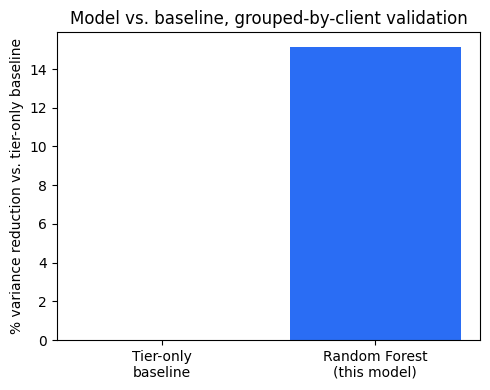

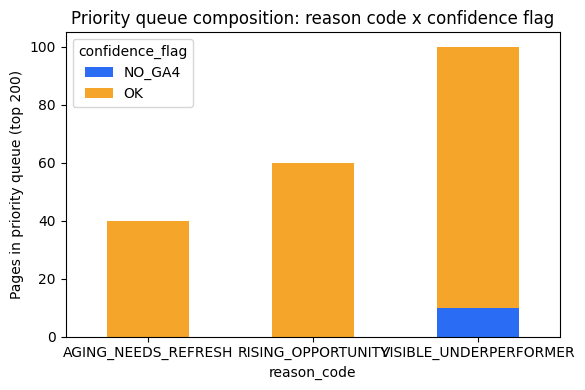

Wrote work/figures/w07_model_vs_baseline.png and work/figures/w07_queue_composition.png


In [15]:
import os, json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

QUEUE_SIZE = sum(QUOTAS.values())
# 1. The priority queue CSV (gitignored, regenerated every run)
queue.to_csv("work/outputs/w07_ranked_queue.csv", index=False)
print(f"Wrote work/outputs/w07_ranked_queue.csv ({len(queue)} rows -- the top {QUEUE_SIZE} priority queue)")

# Secondary reference file: the full eligible pool, not the priority queue
eligible_sorted.to_csv("work/outputs/w07_eligible_pool_full.csv", index=False)
print(f"Wrote work/outputs/w07_eligible_pool_full.csv ({len(eligible_sorted)} rows -- full reference pool)")

# 2. Metrics JSON (committed -- the paper's receipts)
metrics_export = {
    "validated_performance_grouped_split": validated_metrics,
    "queue_composition": {
        "eligible_pool_size": len(eligible_sorted),
        "priority_queue_size": len(queue),
        "reason_code_counts": queue["reason_code"].value_counts().to_dict(),
        "confidence_flag_counts": queue["confidence_flag"].value_counts().to_dict(),
    },
    "own_panel_decay_check": {
        "group_means": own_panel_check.to_dict(),
        "word_count_missing_overall_pct": round(missing_wc / len(q) * 100, 1),
        "word_count_missing_by_group_pct": {
            "underperforming": round(missing_by_group.get(True, float("nan")) * 100, 1),
            "at_or_above_expected": round(missing_by_group.get(False, float("nan")) * 100, 1),
        },
        "word_count_verdict": "inconclusive -- unequal missingness between groups",
    },
    "monitoring_baseline": monitoring_triggers,
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics_export, f, indent=2)
print("Wrote work/outputs/w07_metrics.json")

# 3. Figure -- model vs. tier-only baseline (variance reduction)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Tier-only\nbaseline", "Random Forest\n(this model)"],
       [0, validated_metrics["pct_variance_reduction_vs_tier_baseline"]],
       color=["#999999", "#2a6df4"])
ax.set_ylabel("% variance reduction vs. tier-only baseline")
ax.set_title("Model vs. baseline, grouped-by-client validation")
plt.tight_layout()
plt.savefig("work/figures/w07_model_vs_baseline.png", dpi=150)
plt.show()

# 4. Figure -- priority queue composition (top 200, not the full eligible pool)
fig, ax = plt.subplots(figsize=(6, 4))
composition = queue.groupby(["reason_code", "confidence_flag"]).size().unstack(fill_value=0)
composition.plot(kind="bar", stacked=True, ax=ax, color=["#2a6df4", "#f4a52a", "#cccccc"])
ax.set_ylabel("Pages in priority queue (top 200)")
ax.set_title("Priority queue composition: reason code x confidence flag")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("work/figures/w07_queue_composition.png", dpi=150)
plt.show()

print("Wrote work/figures/w07_model_vs_baseline.png and work/figures/w07_queue_composition.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.